In [1]:
import os

os.environ["JAX_PLATFORM_NAME"] = "cpu"

import joblib
import optax.projections
%load_ext autoreload
%autoreload 2

import jax
import jax.numpy as jnp
import equinox as eqx

import numpy as np
import matplotlib.pyplot as plt

from qdots_qll.distributions import Distribution, update_particles_locations, update_weights

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

from jax import jit
from jax.scipy.linalg import expm

from qdots_qll.models.single_dot_weak_coupling_GAME import *

from qdots_qll.resamplers import LWResamplerBounds

from qdots_qll.exp_design import OptimizeInitialStateMeasurements, MaxDetFimExpDesign

from tensorflow_probability.substrates import jax as tfp
import optax

import jax.tree_util as jtu


def tree_stack(trees):
    return jax.tree.map(lambda *v: jnp.stack(v), *trees)


def tree_unstack(tree):
    leaves, treedef = jax.tree.flatten(tree)
    return [treedef.unflatten(leaf) for leaf in zip(*leaves, strict=True)]


def transpose_results(pytree):
    return tree_stack(list(map(list, zip(*tree_unstack(tree_unstack(pytree))))))


In [2]:
results_adaptive = joblib.load('results_one_qubit/run_2024-05-31_18:36:30')

# results_non_adaptive = joblib.load('results_one_qubit/run_2024-05-31_18:56:59')

In [3]:

def new_transpose_results(pytree):
    return tree_stack(tree_unstack(tree_unstack(pytree)))

In [4]:
dists_adaptive = results_adaptive[2]

In [5]:
new_transpose_results(dists_adaptive)

[Distribution(
   no_rv=i32[25],
   no_particles=i32[25],
   particles_locations=f32[25,1000,4],
   weights=f32[25,1000]
 ),
 Distribution(
   no_rv=i32[25],
   no_particles=i32[25],
   particles_locations=f32[25,1000,4],
   weights=f32[25,1000]
 ),
 Distribution(
   no_rv=i32[25],
   no_particles=i32[25],
   particles_locations=f32[25,1000,4],
   weights=f32[25,1000]
 ),
 Distribution(
   no_rv=i32[25],
   no_particles=i32[25],
   particles_locations=f32[25,1000,4],
   weights=f32[25,1000]
 ),
 Distribution(
   no_rv=i32[25],
   no_particles=i32[25],
   particles_locations=f32[25,1000,4],
   weights=f32[25,1000]
 ),
 Distribution(
   no_rv=i32[25],
   no_particles=i32[25],
   particles_locations=f32[25,1000,4],
   weights=f32[25,1000]
 ),
 Distribution(
   no_rv=i32[25],
   no_particles=i32[25],
   particles_locations=f32[25,1000,4],
   weights=f32[25,1000]
 ),
 Distribution(
   no_rv=i32[25],
   no_particles=i32[25],
   particles_locations=f32[25,1000,4],
   weights=f32[25,1000]
 ),


In [3]:
outcomes_adaptive = results_adaptive[0]
times_adaptive = results_adaptive[1]
dists_adaptive = results_adaptive[2]

results_adaptive = None
dists_adaptive = transpose_results(dists_adaptive)

cov_lists_adaptive = []
for dist_run in dists_adaptive:
    cov_lists_adaptive.append(jax.vmap(lambda dist: dist.cov())(dist_run))

cov_lists_adaptive = np.array(cov_lists_adaptive)

ev_lists_adaptive = []
for dist_run in dists_adaptive:
    ev_lists_adaptive.append(jax.vmap(lambda dist: dist.ev())(dist_run))

ev_lists_adaptive = np.array(ev_lists_adaptive)
times_adaptive = times_adaptive.T
outcomes_adaptive = outcomes_adaptive.transpose(1, 0, 2)

In [ ]:
cov_mean = jnp.mean(
    jax.vmap(lambda cov_list_one_run: jax.vmap(lambda mat: jnp.diag(mat))(cov_list_one_run))(cov_lists_adaptive),
    axis=0)

cov_std = jnp.std(
    jax.vmap(lambda cov_list_one_run: jax.vmap(lambda mat: jnp.diag(mat))(cov_list_one_run))(cov_lists_adaptive),
    axis=0)

plt.hist(times_adaptive.flatten(), bins=100)
plt.show()

for i in range(4):
    plt.plot(cov_mean[:, i])

plt.loglog()

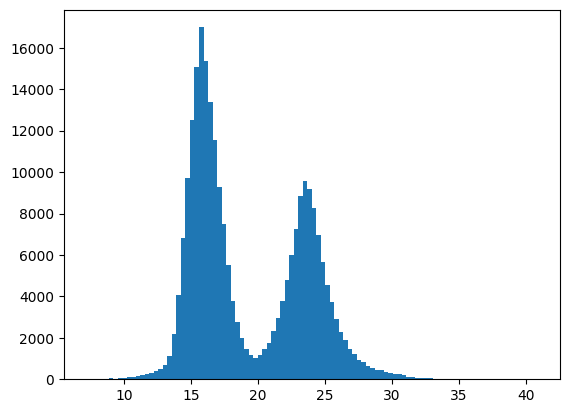

[]

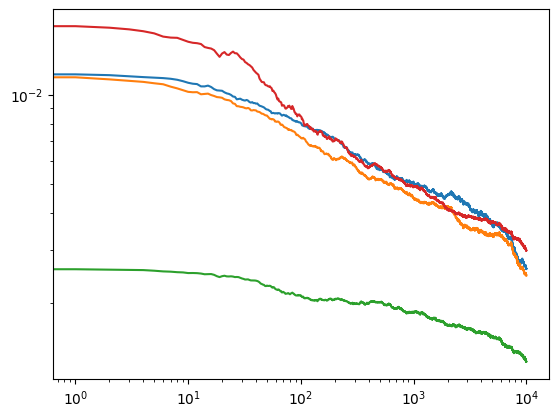

In [4]:
cov_mean = jnp.mean(
    jax.vmap(lambda cov_list_one_run: jax.vmap(lambda mat: jnp.diag(mat))(cov_list_one_run))(cov_lists_adaptive),
    axis=0)

cov_std = jnp.std(
    jax.vmap(lambda cov_list_one_run: jax.vmap(lambda mat: jnp.diag(mat))(cov_list_one_run))(cov_lists_adaptive),
    axis=0)

plt.hist(times_adaptive.flatten(), bins=100)
plt.show()

for i in range(4):
    plt.plot(cov_mean[:, i])

plt.loglog()